# F_behavior_w_FP.ipynb

## Purpose

Identical behavioral analysis restricted to sessions with simultaneous fiber photometry (FP) recordings, using the photometry-session subset.

## Manuscript figure panels

- (Photometry subset)

## Prerequisites

Before running this notebook, ensure the figure preparation scripts have been run in sequence (see `/root/capsule/code/beh_ephys_analysis/session_combine/figure_preparation/sequence`).

Required input files:
- `combined_beh_sessions.pkl` filtered for photometry sessions

In [108]:
import sys
import os
from matplotlib.colors import LinearSegmentedColormap
# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
import pathlib

# Resolve code/beh_ephys_analysis (the folder containing `utils`) relative to this
# file's location, so imports work no matter where the repo is checked out.
try:
    _here = pathlib.Path(__file__).resolve().parent          # script mode
except NameError:
    try:
        _here = pathlib.Path(__vsc_ipynb_file__).resolve().parent  # VS Code notebook
    except NameError:
        _here = pathlib.Path(os.getcwd())                    # other Jupyter fallback

_beh_ephys_root = str((_here / '../..').resolve())
if _beh_ephys_root not in sys.path:
    sys.path.insert(0, _beh_ephys_root)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pynwb import NWBFile, TimeSeries, NWBHDF5IO
from scipy.io import loadmat
from scipy.stats import zscore
from pathlib import Path
import glob
import json
import seaborn as sns
from PyPDF2 import PdfMerger
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import re
from utils.beh_functions import session_dirs, parseSessionID, load_model_dv, makeSessionDF, get_session_tbl, get_unit_tbl, get_history_from_nwb, fit_glm_session_list
from utils.combine_tools import apply_qc, to_str_intlike, spatial_dependence_summary, binary_shift_P_vs_U, welch_shift_P_vs_U
from utils.lick_utils import load_licks
from utils.capsule_migration import capsule_directories
import pickle
import scipy.stats as stats
import spikeinterface as si
import shutil
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import r2_score
import warnings
from scipy.stats import gaussian_kde
import trimesh
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from utils.ccf_utils import ccf_pts_convert_to_mm
from trimesh import load_mesh
from scipy.stats import pearsonr
from aind_ephys_utils import align
import k3d
from scipy.stats import rankdata
from scipy.ndimage import binary_dilation
from skimage.measure import find_contours
warnings.filterwarnings('ignore')
capsule_dirs = capsule_directories()
%matplotlib inline
from utils.capsule_migration import CAPSULE_ROOT
from utils.panel_utils import save_panels, save_panel_csv, columns_to_df, heatmap_to_df


## Data Loading and Initialization

Load the combined session table from the manuscript figure preparation pipeline. This dataset has been filtered to include only sessions with fiber photometry recordings. We apply behavioral quality control criteria to ensure sessions meet minimum performance standards for inclusion in the analysis.

## Quality metrics

In [109]:
# load animal parameters
pickle_file = os.path.join(capsule_dirs["manuscript_fig_prep_dir"], 'combined_session_tbl', 'combined_beh_sessions.pkl')
target_folder = os.path.join(capsule_dirs["manuscript_fig_dir"], 'F_beh')
if not os.path.exists(target_folder):
    os.makedirs(target_folder)
with open(pickle_file, 'rb') as f:
    combined_session_tbl = pickle.load(f)
combined_session_tbl.loc[combined_session_tbl['p_st_w']==1, 'diff_1'] = 5
combined_session_tbl['p_sw_L-W' ] = combined_session_tbl['p_sw_L'] - (1 - combined_session_tbl['p_st_w'])

## Behavioral Quality Control

Apply quality metrics filtering based on behavioral criteria defined in `beh_only.json`. This ensures that only sessions with adequate task engagement, choice variability, and performance levels are included in subsequent analyses. The filtering visualizes which sessions pass or fail each quality criterion.

Applying bounds for session_len: [90, None]
 - session_len: 345 -> 344 units passed
Applying bounds for p_sw_L: [0.04, None]
 - p_sw_L: 344 -> 341 units passed
Applying bounds for aN: [0.15, None]
 - aN: 341 -> 278 units passed
Applying bounds for diff_1: [0, None]
 - diff_1: 278 -> 277 units passed
Applying bounds for bias: [-1.25, 1.25]
 - bias: 277 -> 259 units passed
Number of opto rows after filtering: 259
Number of non-opto rows after filtering: 259


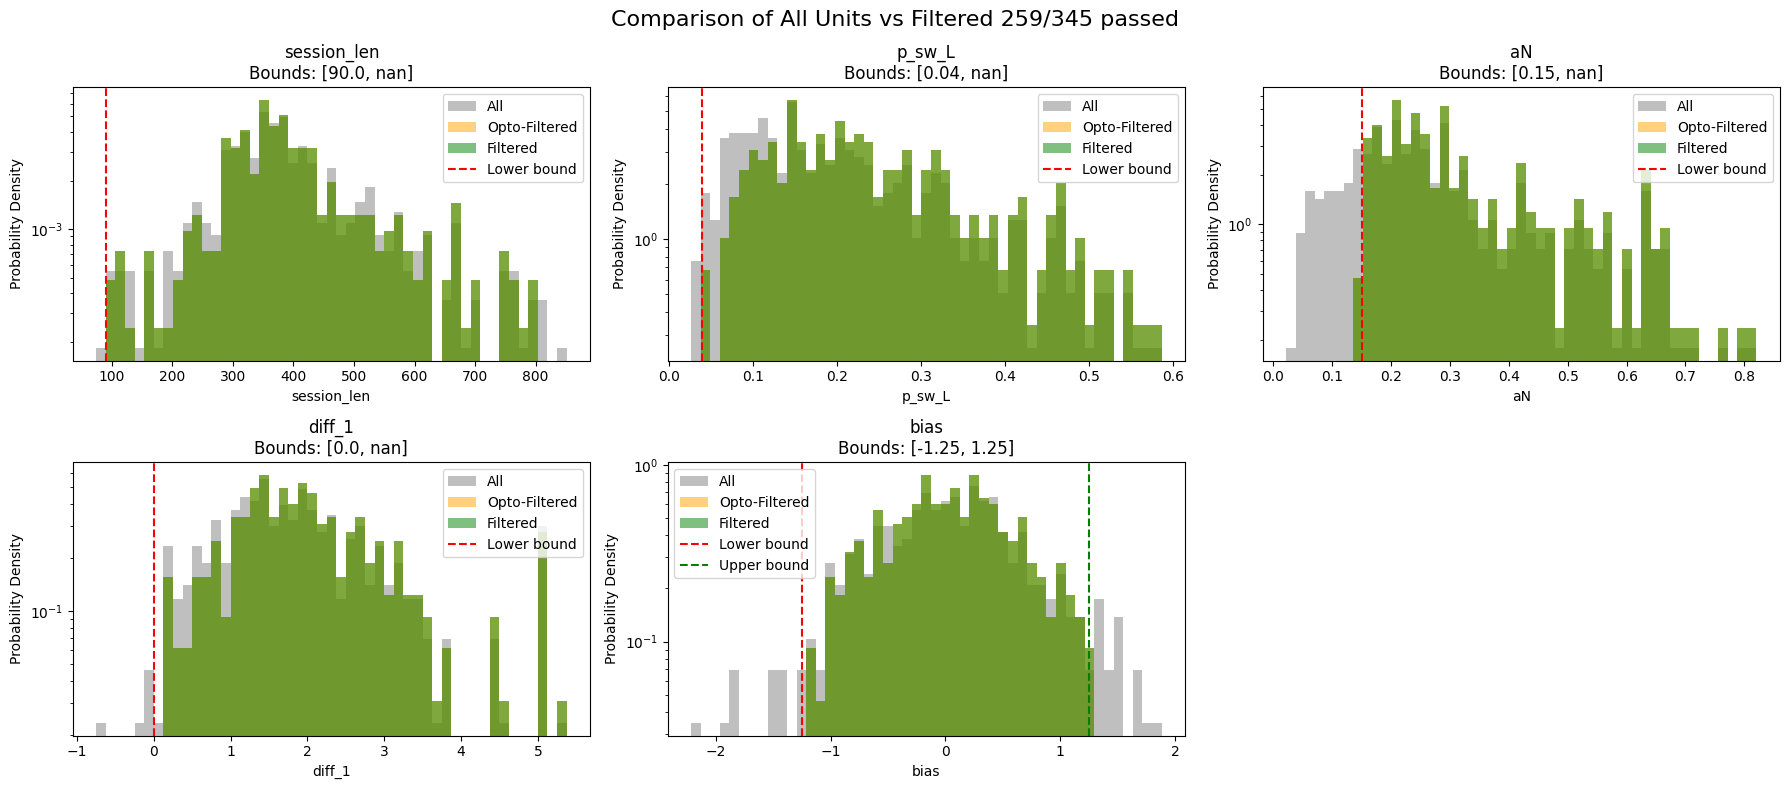

In [110]:
beh_criteria = 'beh_only'
with open(os.path.join(CAPSULE_ROOT + '/code/beh_ephys_analysis/session_combine/metrics', f'{beh_criteria}.json'), 'r') as f:
    beh_constraints = json.load(f)
combined_session_tbl_filtered, combined_session_tbl, fig, axes = apply_qc(combined_session_tbl, beh_constraints)

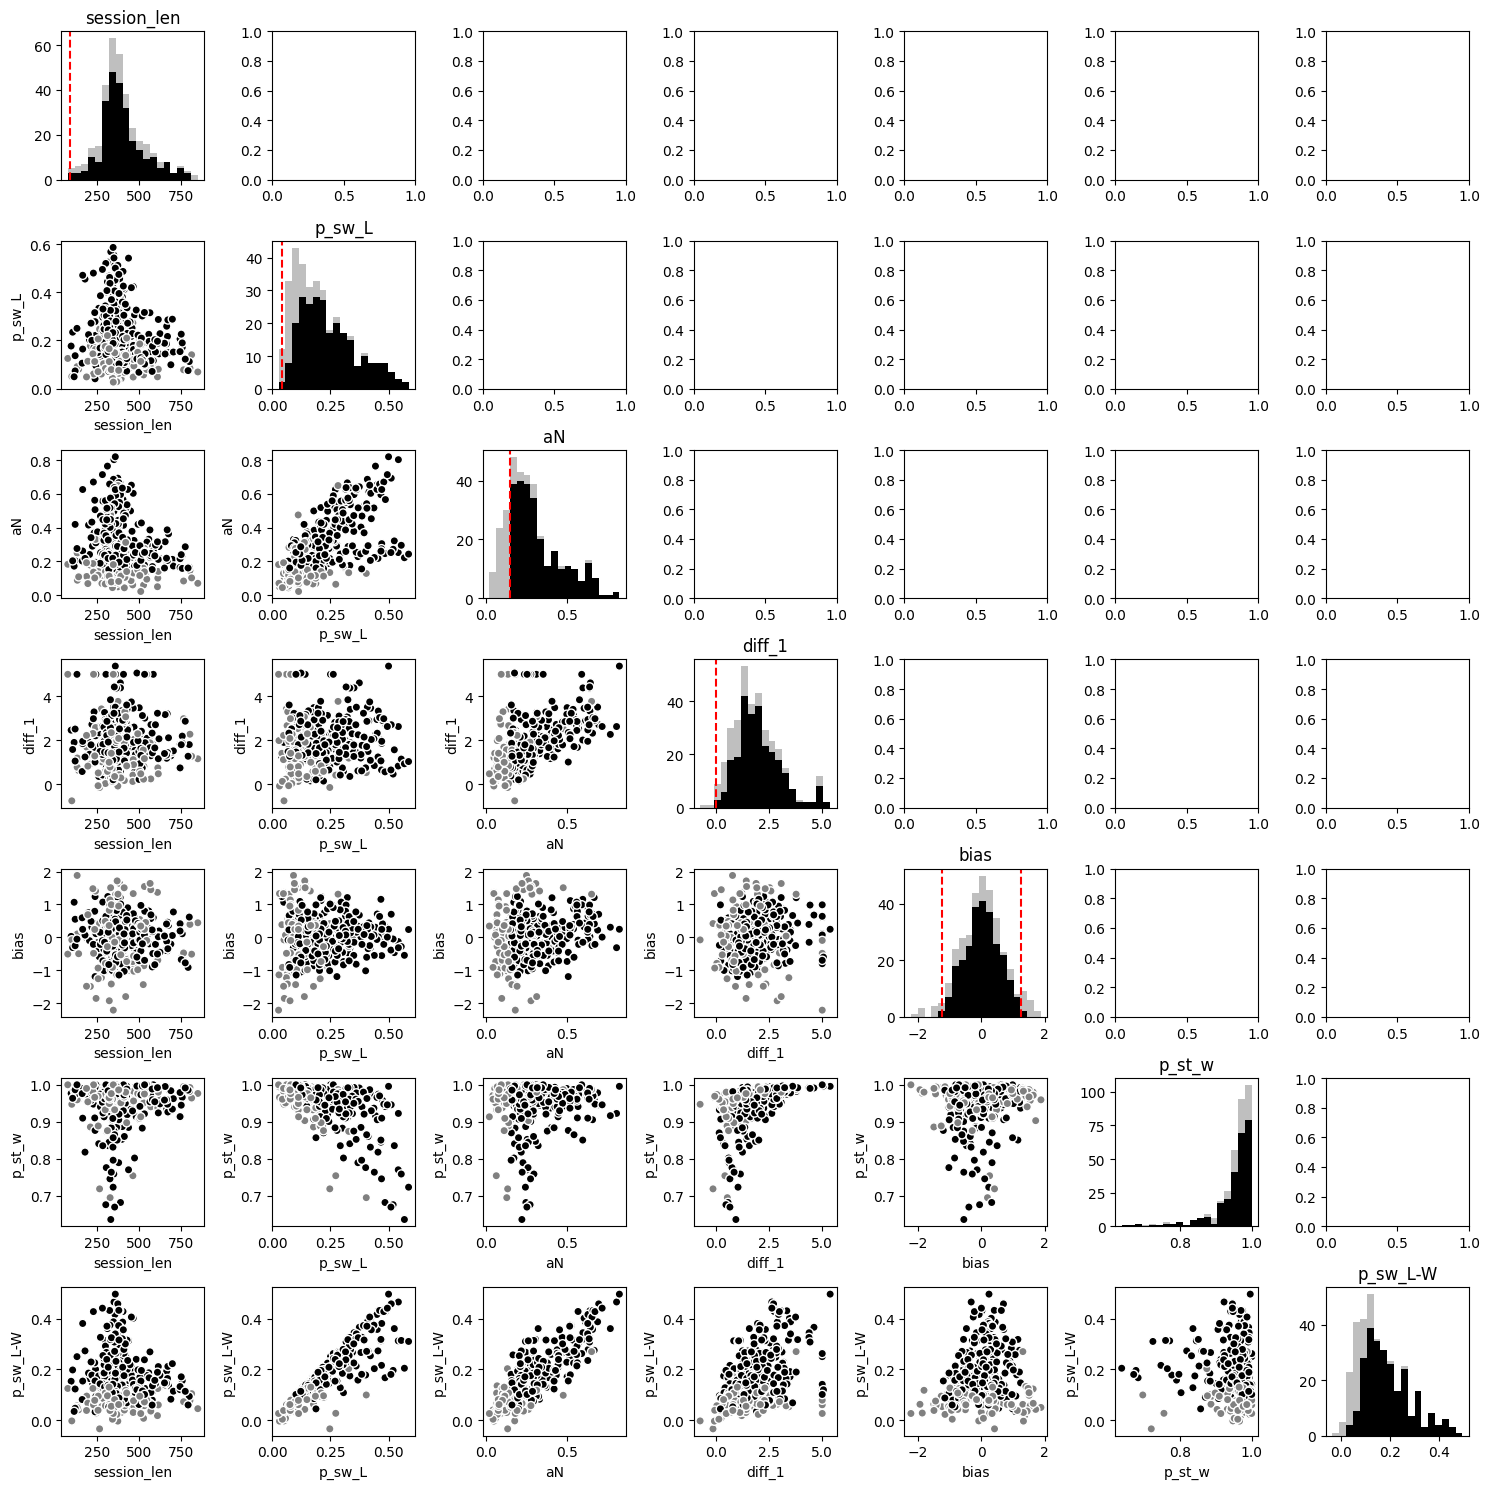

In [111]:
# scatter plot of qm_cols and color code pass vs fail
qm_cols = list(beh_constraints.keys())
qm_cols.append('p_st_w')
qm_cols.append('p_sw_L-W')
fig, axes = plt.subplots(len(qm_cols), len(qm_cols), figsize=(15,15))
for i, col_x in enumerate(qm_cols):
    for j, col_y in enumerate(qm_cols):
        ax = axes[j, i]
        if i == j:
            bins = np.linspace(combined_session_tbl[col_x].min(), combined_session_tbl[col_x].max(), 20)
            ax.hist(combined_session_tbl[col_x].dropna(), bins=bins, edgecolor=None, facecolor = 'gray', alpha=0.5)
            ax.hist(combined_session_tbl_filtered[col_x].dropna(), bins=bins, edgecolor=None, facecolor = 'k', alpha=1)
            ax.set_title(col_x)
            if col_x in beh_constraints.keys():
                for boundary in beh_constraints[col_x]['bounds']:
                    if boundary is not None:
                        ax.axvline(boundary, color='red', linestyle='--')

        elif i < j:
            ax.scatter(combined_session_tbl[col_x], combined_session_tbl[col_y], 
                        c=combined_session_tbl['session_id'].isin(combined_session_tbl_filtered['session_id']).map({True: 'k', False: 'gray'}), 
                        alpha=1, edgecolors='white')
    
            ax.set_xlabel(col_x)
            ax.set_ylabel(col_y)
plt.tight_layout()

plt.savefig(os.path.join(target_folder, 'behavior_qm_scatter.pdf'))

## Generalized Linear Model (GLM) Analysis

Implement a logistic regression framework to model how choice behavior depends on reward history and previous choices. We fit multiple GLM variants to disentangle the contributions of rewarded vs unrewarded outcomes and to model both choice probability and switch probability. The parallelized implementation concatenates trials across sessions for robust parameter estimation.

In [112]:
# results, fig = fit_glm_session_list(combined_session_tbl_filtered['session'].to_list(), plot=True)

In [113]:
from joblib import Parallel, delayed
import numpy as np
import statsmodels.api as sm
from scipy.optimize import curve_fit


def prepare_glm_session(sess, max_lag=5, model_name='stan_qLearning_5params'):
    """
    Prepare per-session design matrices and targets for GLM fitting.
    Returns None if session is invalid.
    """
    if get_session_tbl(sess) is None:
        return None

    sess_df = makeSessionDF(
        sess,
        cut_interruptions=True,
        model_name=model_name
    )

    if sess_df is None or len(sess_df) == 0:
        return None

    choice_raw = sess_df['choice'].values.copy()
    choice = 2 * (choice_raw - 0.5)   # {-1, +1}
    choice_prev = sess_df['choices_prev'].values
    choice_prev = 2 * (choice_prev - 0.5)   # {-1, +1}
    outcome = sess_df['outcome'].values

    reward_side = choice * outcome
    noreward_side = choice * (1 - outcome)

    n_trials = len(choice)

    reward_side_hist_mat = np.full((n_trials, max_lag), np.nan)
    noreward_side_hist_mat = np.full((n_trials, max_lag), np.nan)
    choice_hist_mat = np.full((n_trials, max_lag), np.nan)
    choice_hist_mat_for_switch = np.full((n_trials, max_lag), np.nan)

    for lag in range(1, max_lag + 1):
        reward_side_hist_mat[lag:, lag - 1] = reward_side[:-lag]
        noreward_side_hist_mat[lag:, lag - 1] = noreward_side[:-lag]
        choice_hist_mat[lag:, lag - 1] = choice[:-lag]
        choice_hist_mat_for_switch[(lag+1):, lag - 1] = choice[:-(lag+1)]

    return {
        'session': sess,
        'reward_side_hist_mat': reward_side_hist_mat,
        'noreward_side_hist_mat': noreward_side_hist_mat,
        'choice_hist_mat': choice_hist_mat,
        'choice_hist_mat_for_switch': choice_hist_mat_for_switch,
        'choices': choice_raw,
        'choices_prev': choice_prev,
        'session_len': n_trials,
    }


def fit_glm_session_list_par(
    session_list,
    max_lag=5,
    plot=False,
    n_jobs=-1,
    backend='loky',
    model_name='stan_qLearning_5params',
    fit_kwargs=None,
    return_dict=False,
):
    """
    Parallelized GLM fitting across sessions while concatenating trials across sessions.

    Returns
    -------
    By default:
        result_rwd_choice,
        result_rwd_norwd,
        result_switch_rwd_norwd,
        result_switch_norwd_choice,
        result_switch_rwd_choice,
        choice_prob_by_session,
        switch_prob_by_session

    If return_dict=True:
        returns a dict with the same contents.
    """
    if fit_kwargs is None:
        fit_kwargs = {'disp': False}

    prepared = Parallel(n_jobs=n_jobs, backend=backend)(
        delayed(prepare_glm_session)(sess, max_lag=max_lag, model_name=model_name)
        for sess in session_list
    )

    prepared = [x for x in prepared if x is not None]

    if len(prepared) == 0:
        raise ValueError("No valid sessions found in the provided session list.")

    session_list_valid = [x['session'] for x in prepared]
    session_lens = [x['session_len'] for x in prepared]

    all_reward_side_hist_mat = np.vstack([x['reward_side_hist_mat'] for x in prepared])
    all_noreward_side_hist_mat = np.vstack([x['noreward_side_hist_mat'] for x in prepared])
    all_choice_hist_mat = np.vstack([x['choice_hist_mat'] for x in prepared])
    all_choice_hist_mat_for_switch = np.vstack([x['choice_hist_mat_for_switch'] for x in prepared])
    all_choices = np.hstack([x['choices'] for x in prepared])
    all_choices_prev = np.hstack([x['choices_prev'] for x in prepared])

    # 1) choice ~ reward side + choice history
    X = np.hstack([all_reward_side_hist_mat, all_choice_hist_mat])
    X = sm.add_constant(X, has_constant='add')
    model = sm.Logit(all_choices, X, missing='drop')
    result_rwd_choice = model.fit(**fit_kwargs)

    # 2) choice ~ reward side + no-reward side
    X = np.hstack([all_reward_side_hist_mat, all_noreward_side_hist_mat])
    X = sm.add_constant(X, has_constant='add')
    model = sm.Logit(all_choices, X, missing='drop')
    result_rwd_norwd = model.fit(**fit_kwargs)

    # 3) switch ~ reward side*prev_choice + no-reward side*prev_choice
    all_reward_side_hist_mat_inter = all_reward_side_hist_mat * all_choices_prev[:, np.newaxis]
    all_noreward_side_hist_mat_inter = all_noreward_side_hist_mat * all_choices_prev[:, np.newaxis]
    all_choices_switch = (all_choices != all_choices_prev).astype(float)
    valid_idx = ~np.isnan(all_choices_prev)

    X = np.hstack([
        all_reward_side_hist_mat_inter[valid_idx],
        all_noreward_side_hist_mat_inter[valid_idx]
    ])
    X = sm.add_constant(X, has_constant='add')
    model = sm.Logit(all_choices_switch[valid_idx], X, missing='drop')
    result_switch_rwd_norwd = model.fit(**fit_kwargs)

    # 4) switch ~ no-reward side*prev_choice + choice history*prev_choice
    all_noreward_side_hist_mat_inter = all_noreward_side_hist_mat * all_choices_prev[:, np.newaxis]
    all_choice_hist_mat_inter = all_choice_hist_mat_for_switch * all_choices_prev[:, np.newaxis]

    X = np.hstack([
        all_noreward_side_hist_mat_inter[valid_idx],
        all_choice_hist_mat_inter[valid_idx]
    ])
    X = sm.add_constant(X, has_constant='add')
    model = sm.Logit(all_choices_switch[valid_idx], X, missing='drop')
    result_switch_norwd_choice = model.fit(**fit_kwargs)

    # 5) switch ~ reward side*prev_choice + choice history*prev_choice
    all_reward_side_hist_mat_inter = all_reward_side_hist_mat * all_choices_prev[:, np.newaxis]
    all_choice_hist_mat_inter = all_choice_hist_mat_for_switch * all_choices_prev[:, np.newaxis]

    X = np.hstack([
        all_reward_side_hist_mat_inter[valid_idx],
        all_choice_hist_mat_inter[valid_idx]
    ])
    X = sm.add_constant(X, has_constant='add')
    model = sm.Logit(all_choices_switch[valid_idx], X, missing='drop')
    result_switch_rwd_choice = model.fit(**fit_kwargs)

    # # 5) switch ~ no-reward side*prev_choice + reward side*prev_choice + choice history*prev_choice
    # all_reward_side_hist_mat_inter = all_reward_side_hist_mat * all_choices_prev[:, np.newaxis]
    # all_noreward_side_hist_mat_inter = all_noreward_side_hist_mat * all_choices_prev[:, np.newaxis]
    # all_choice_hist_mat_inter = all_choice_hist_mat_for_switch * all_choices_prev[:, np.newaxis]
    # valid_idx = ~np.isnan(all_choices_prev)
    # X = np.hstack([
    #     all_reward_side_hist_mat_inter[valid_idx],
    #     all_noreward_side_hist_mat_inter[valid_idx],
    #     all_choice_hist_mat_inter[valid_idx]
    # ])
    # X = sm.add_constant(X, has_constant='add')
    # model = sm.Logit(all_choices_switch[valid_idx], X, missing='drop')
    # result_switch_full = model.fit(**fit_kwargs)

    # choice probability from model 1
    X_pred = np.hstack([all_reward_side_hist_mat, all_choice_hist_mat])
    X_pred = sm.add_constant(X_pred, has_constant='add')
    choice_prob = result_rwd_choice.predict(X_pred)

    left_choices = all_choices == 0
    choice_prob[left_choices] = 1 - choice_prob[left_choices]

    # switch probability from model 4
    X_pred_switch = np.hstack([
        all_noreward_side_hist_mat_inter[valid_idx],
        all_choice_hist_mat_inter[valid_idx]
    ])
    X_pred_switch = sm.add_constant(X_pred_switch, has_constant='add')
    switch_prob_valid = result_switch_norwd_choice.predict(X_pred_switch)

    switch_prob = np.full(len(all_choices), np.nan)
    switch_prob[valid_idx] = switch_prob_valid


    # split back by session
    choice_prob_by_session = {}
    switch_prob_by_session = {}

    start_idx = 0
    for sess, sess_len in zip(session_list_valid, session_lens):
        end_idx = start_idx + sess_len
        choice_prob_by_session[sess] = choice_prob[start_idx:end_idx]
        switch_prob_by_session[sess] = switch_prob[start_idx:end_idx]
        start_idx = end_idx


    results = {
        "models": {
            "choice_reward_choice": result_rwd_choice,
            "choice_reward_noreward": result_rwd_norwd,
            "switch_reward_noreward": result_switch_rwd_norwd,
            "switch_noreward_choice": result_switch_norwd_choice,
            "switch_reward_choice": result_switch_rwd_choice,
            # "switch_full": result_switch_full,
        },

        "choice_prob_by_session": choice_prob_by_session,
        "switch_prob_by_session": switch_prob_by_session,

        "session_list_valid": session_list_valid,
        "session_lens": session_lens,
        "max_lag": max_lag
    }

    return results


def _fit_exp_offset(lags, betas, ses=None):
    """Fit y = A * exp(-lag/tau) + C. Returns (A, tau, C) or None on failure.

    Uses inverse-variance weighting when standard errors are provided.
    Auto-orients: if the curve is largely negative, fits -y and negates A/C.
    """
    lags = np.asarray(lags, dtype=float)
    y = np.asarray(betas, dtype=float)
    ok = np.isfinite(y)
    if ses is not None:
        ses = np.asarray(ses, dtype=float)
        ok &= np.isfinite(ses) & (ses > 0)
    if ok.sum() < 4:
        return None
    x_fit = lags[ok]
    y_fit = y[ok]
    sigma = ses[ok] if ses is not None else None

    sign = 1.0
    if np.nanmean(y_fit) < 0:
        y_fit = -y_fit
        sign = -1.0

    def model(x, A, tau, C):
        return A * np.exp(-x / tau) + C

    A0 = float(y_fit[0] - y_fit[-1]) if len(y_fit) >= 2 else float(y_fit[0])
    if A0 == 0:
        A0 = 1e-3
    tau0 = float(max((x_fit.max() - x_fit.min()) / 3.0, 1e-3))
    C0 = float(y_fit[-1])
    try:
        popt, _ = curve_fit(
            model, x_fit, y_fit,
            p0=[A0, tau0, C0],
            sigma=sigma,
            absolute_sigma=sigma is not None,
            maxfev=10000,
            bounds=([-np.inf, 1e-3, -np.inf], [np.inf, np.inf, np.inf]),
        )
    except Exception:
        return None
    A, tau, C = popt
    return sign * A, tau, sign * C


def plot_glm_session_results(results, figsize=None, sharey=False):

    models = results["models"]
    max_lag = results["max_lag"]

    # (key, title, labels, fit_exp_flags) — fit_exp_flags is per-curve.
    # A flag of True fits y = A*exp(-lag/tau) + C to that curve and annotates on axis.
    model_specs = [
        ("choice_reward_choice",
         "Choice: reward + choice",
         ["Reward side", "Choice history"],
         [True, True]),

        ("choice_reward_noreward",
         "Choice: reward + no-reward",
         ["Reward side", "No-reward side"],
         [True, True]),

        ("switch_noreward_choice",
         "Switch: no-reward + choice",
         ["No-reward × prev", "Choice × prev"],
         [True, True]),

        ("switch_reward_choice",
         "Switch: reward + choice",
         ["Reward × prev", "Choice × prev"],
         [False, False]),

        #  ("switch_full",
        #  "Switch: reward + no-reward + choice",
        #  ["Reward × prev", "No-reward × prev", "Choice × prev"],
        #  [True, True, True])
    ]
    if figsize is None:
        figsize = (5*len(model_specs), 5)
    fig, axes = plt.subplots(1,len(model_specs),figsize=figsize,sharey=sharey)
    axes = axes.flatten()

    lags = np.arange(1, max_lag+1)
    dense_lags = np.linspace(lags[0], lags[-1], 200)

    any_fit = False

    for ax, spec in zip(axes, model_specs):
        key, title, labels = spec[0], spec[1], spec[2]
        fit_flags = spec[3] if len(spec) > 3 else [False] * len(labels)

        result = models[key]

        params = np.asarray(result.params)
        bse = np.asarray(result.bse)

        beta1 = params[1:1+max_lag]
        beta2 = params[1+max_lag:1+2*max_lag]

        err1 = bse[1:1+max_lag]
        err2 = bse[1+max_lag:1+2*max_lag]

        line1 = ax.errorbar(lags, beta1, yerr=err1, marker="o", label=labels[0])
        line2 = ax.errorbar(lags, beta2, yerr=err2, marker="o", label=labels[1])

        fit_texts = []
        for lab, beta, err, flag, artist in [
            (labels[0], beta1, err1, fit_flags[0], line1),
            (labels[1], beta2, err2, fit_flags[1], line2),
        ]:
            if not flag:
                continue
            any_fit = True
            fit = _fit_exp_offset(lags, beta, err)
            if fit is None:
                fit_texts.append(f'{lab}: exp fit failed')
                continue
            A, tau, C = fit
            color = artist[0].get_color()
            ax.plot(dense_lags, A * np.exp(-dense_lags / tau) + C, color=color, ls='--', lw=1.2)
            fit_texts.append(f'{lab}: A={A:.4f}, τ={tau:.4f}, C={C:.4f}')

        if fit_texts:
            ax.text(0.98, 0.02, '\n'.join(fit_texts), transform=ax.transAxes,
                    ha='right', va='bottom', fontsize=8,
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

        ax.axhline(0, ls="--", lw=1)
        ax.set_title(title)
        ax.set_xlabel("Lag")
        ax.set_xticks(lags)
        ax.legend(frameon=False)

    axes[0].set_ylabel("Coefficient")

    for ax in axes[len(model_specs):]:
        ax.axis("off")

    if any_fit:
        fig.suptitle(
            r'Exponential fit: $\beta(\mathrm{lag}) = A \cdot e^{-\mathrm{lag}/\tau} + C$    '
            r'($A$ = amplitude, $\tau$ = decay in lags, $C$ = asymptote)',
            fontsize=10, y=1.02,
        )

    plt.tight_layout()

    return fig,axes

In [114]:
results = fit_glm_session_list_par(combined_session_tbl_filtered['session'].to_list(), n_jobs=12, max_lag=10)

0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

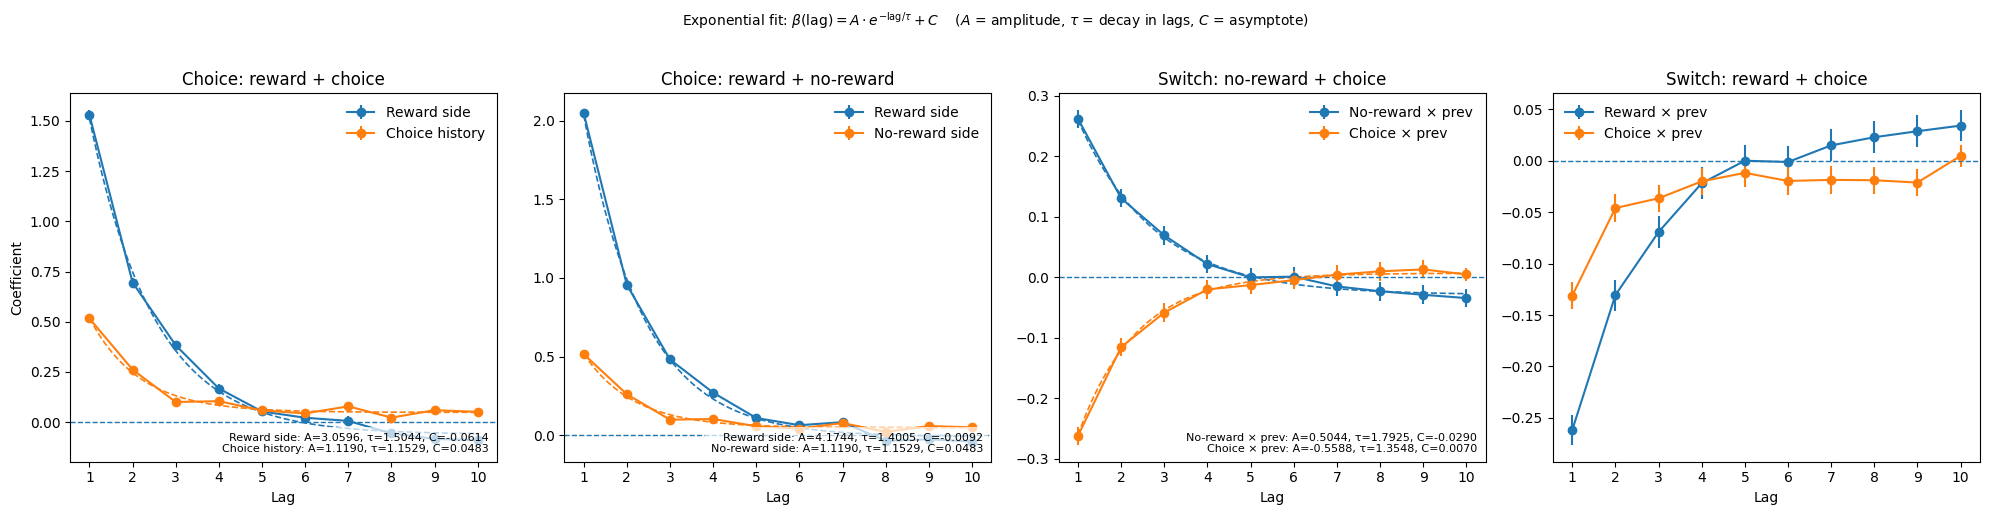

In [115]:
fig, _ = plot_glm_session_results(results);
save_panels(fig, target_folder, 'glm_combined_sessions', ['Figure4c', 'Figure5e'], exts=('pdf',))
# ---- panel CSVs (rule 5 errorbar; rule 9 map: Figure4c=choice_reward_choice, Figure5e=switch_noreward_choice; Figure5a NOT in this panel) ----
_max_lag = results['max_lag']; _lags = np.arange(1, _max_lag + 1)
for _panel, _key, _l0, _l1 in [('Figure4c', 'choice_reward_choice', 'reward_side', 'choice_history'), ('Figure5e', 'switch_noreward_choice', 'noreward_x_prevchoice', 'choice_x_prevchoice')]:
    _r = results['models'][_key]; _pp = np.asarray(_r.params); _bb = np.asarray(_r.bse)
    save_panel_csv(columns_to_df(lag=_lags, **{f'{_l0}_coef': _pp[1:1 + _max_lag], f'{_l0}_se': _bb[1:1 + _max_lag], f'{_l1}_coef': _pp[1 + _max_lag:1 + 2 * _max_lag], f'{_l1}_se': _bb[1 + _max_lag:1 + 2 * _max_lag]}), target_folder, 'glm_combined_sessions', [_panel])
##Figure4c##
##Figure5e##

In [94]:
# # test _prepare_glm_session on one session
# test_sess = combined_session_tbl_filtered['session'].iloc[0]
# prepared = _prepare_glm_session(test_sess, max_lag=5)

## Quality Metrics Visualization

Generate a comprehensive pairwise scatter plot matrix of all behavioral quality metrics. This visualization shows the relationships between different quality measures and highlights which sessions passed the filtering criteria (black) versus those that were excluded (gray). Red dashed lines indicate the threshold boundaries defined in the quality control constraints.

## Session-Level Data Processing

Process each behavioral session to extract trial-by-trial variables including Q-values, reward prediction errors (RPE), choice probabilities, and policy metrics. We also compute post-outcome lick rates as a behavioral readout of reward expectation and motivational state. This parallelized processing generates a unified dataframe combining data across all quality-controlled sessions.

In [116]:
session_list = combined_session_tbl_filtered['session_id'].tolist()
model_name = 'stan_qLearning_5params'

In [117]:
# comcation of all sessionss
# pe, p_Right, Q_R, Q_L, policy_change, policy_update_mean etc
focus_cols = ['outcome', 'choice',
                'Q_r', 'Q_l', 'pe', 'p_Right', 'p_Right_glm', 'pChoice', 'pChoice_glm',
                'policy_change', 'policy_change_log_odd', 'policy_update_mean', 
                'policy_glm_change', 'policy_glm_change_log_odd', 'policy_glm_update_mean']
count_win = [0, 1]
def process(session):
    print(session)
    if get_session_tbl(session) is not None:
        sess_df = makeSessionDF(session, model_name=model_name, cut_interruptions=True, load_glm=True)
        if 'pChoice' in sess_df.columns:
             # compute p_Right
            p_right = sess_df['pChoice'].values.copy()
            p_right[sess_df['choice']==0] = 1 - p_right[sess_df['choice']==0]
            sess_df['p_Right'] = p_right
        if 'pChoice_glm' in sess_df.columns:
            p_right_glm = sess_df['pChoice_glm'].values.copy()
            p_right_glm[sess_df['choice']==0] = 1 - p_right_glm[sess_df['choice']==0]
            sess_df['p_Right_glm'] = p_right_glm
        else:
            print(f'No glm for {session}')
        # select focus columns that is included in the session dataframe and set the ones that are not included to NaN
        # count number of licks after outcome
        lick_data = load_licks(session)
        all_licks = np.concatenate((lick_data['licks_L_cleaned'], lick_data['licks_R_cleaned']))
        all_licks = np.sort(all_licks)
        align_times = sess_df['outcome_time'].values
        lick_counts = np.full(len(align_times), np.nan)
        for i, align_time in enumerate(align_times):
            lick_counts[i] = np.sum((all_licks >= align_time + count_win[0]) & (all_licks < align_time + count_win[1]))
        sess_df['lick_rate_post_outcome'] = lick_counts/(count_win[1]-count_win[0])

        for col in focus_cols:
            if col not in sess_df.columns:
                sess_df[col] = np.nan
        return sess_df, session
    else:
        return None, session
        


In [118]:
from joblib import Parallel, delayed
results = Parallel(n_jobs=-1)(delayed(process)(session) for session in session_list)
# all_sess_df = pd.concat(all_sess_dfs, ignore_index=True)

behavior_716325_2024-05-29_10-33-32
behavior_751769_2025-01-16_11-32-05
behavior_751004_2024-12-22_13-09-17
behavior_751769_2025-01-17_11-37-39
behavior_758017_2025-02-04_11-57-38
behavior_758017_2025-02-05_11-42-34
behavior_751766_2025-02-13_11-31-21
behavior_758017_2025-02-06_11-26-14
behavior_751769_2025-01-18_10-15-25
behavior_751766_2025-02-14_11-37-11
behavior_751766_2025-02-11_11-53-38
behavior_751766_2025-02-15_12-08-11


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0

behavior_751181_2025-02-25_12-12-35
behavior_758018_2025-03-21_11-00-34
behavior_751181_2025-02-26_11-51-19
behavior_752014_2025-03-26_11-18-57
behavior_752014_2025-03-27_12-03-59
behavior_752014_2025-03-28_11-04-59
behavior_761038_2025-04-15_10-25-11
behavior_754897_2025-03-12_12-23-15
behavior_761038_2025-04-16_10-39-10
behavior_758018_2025-03-20_11-53-05
behavior_761038_2025-04-18_12-37-39
behavior_782394_2025-04-23_10-51-17
behavior_782394_2025-04-24_12-07-34
behavior_782394_2025-04-25_11-13-21
behavior_763590_2025-05-01_10-59-18
behavior_763590_2025-05-02_11-07-09
behavior_781166_2025-05-13_14-04-27
behavior_781166_2025-05-14_14-18-28
behavior_781166_2025-05-15_14-20-51
behavior_781166_2025-05-16_14-16-34
behavior_785956_2025-05-20_14-15-19
behavior_785956_2025-05-21_13-42-02
behavior_785956_2025-05-23_13-45-21
behavior_784806_2025-06-17_14-59-23
behavior_784806_2025-06-18_13-39-50
behavior_784806_2025-06-20_13-39-16
behavior_791691_2025-06-24_13-21-29
behavior_791691_2025-06-25_1

In [119]:
all_sess_df, processed_sessions = [], []
for res in results:
    if res[0] is not None:
        all_sess_df.append(res[0])
        processed_sessions.append(res[1])

In [120]:
for sess_id, sess_df in enumerate(all_sess_df):
    if sess_df is None or sess_df.empty:
        print(f'Session {processed_sessions[sess_id]} is empty')
        continue
    if 'outcome' not in sess_df.columns:
        print(f'Outcome not in {processed_sessions[sess_id]}')

In [126]:
session_len = [len(sess_df) for sess_df in all_sess_df]
session_len_time = [(sess_df['goCue_start_time'].iloc[-1] - sess_df['goCue_start_time'].iloc[0])/60 if sess_df is not None else np.nan for sess_df in all_sess_df]
p_correct = [np.mean(sess_df['pChoice']>=0.5) if sess_df is not None and 'pChoice' in sess_df.columns else np.nan for sess_df in all_sess_df]
# set p_correct is 0 to np.nan
p_correct = [p if p>0 else np.nan for p in p_correct]

p_correct_glm = [np.mean(sess_df['pChoice_glm']>=0.5) if sess_df is not None and 'pChoice_glm' in sess_df.columns else np.nan for sess_df in all_sess_df]
# set p_correct_glm is 0 to np.nan
p_correct_glm[p_correct_glm == 0]  = np.nan
reward_rate = [np.mean(sess_df['outcome']) if sess_df is not None else np.nan for sess_df in all_sess_df ]


In [127]:

summary_df = pd.DataFrame({'session_id': processed_sessions,
                            'session_len': session_len,
                            'session_len_time': session_len_time,
                            'p_correct': p_correct,
                            # 'p_correct_glm': p_correct_glm,
                            'reward_rate': reward_rate})



['/root/capsule/scratch/results/manuscript/figures/F_beh/FigureS12a_behavior_summary_stats_histogram.csv']

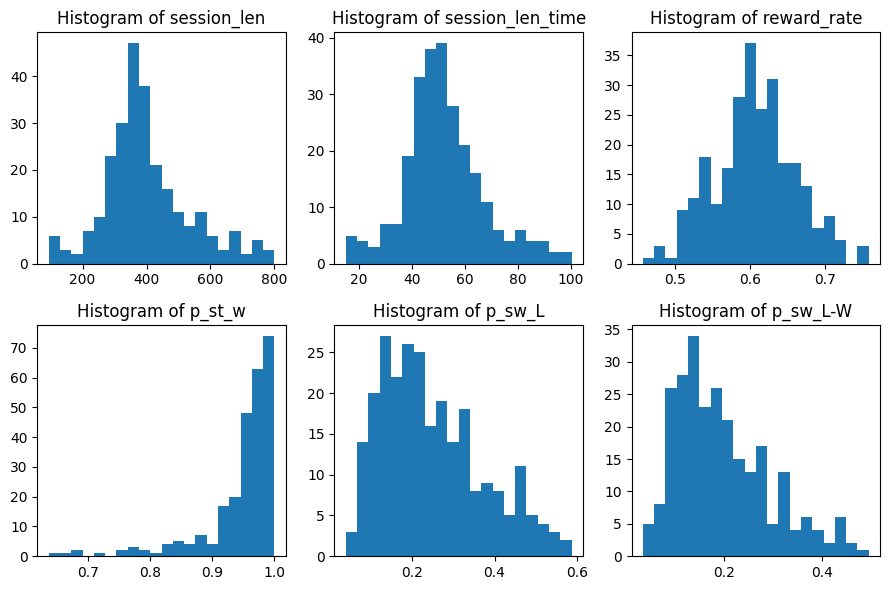

In [128]:
# histogram of all summary stats
summary_df = summary_df.merge(combined_session_tbl[['p_st_w', 'p_sw_L', 'p_sw_L-W', 'session_id']], on=['session_id'])
focus_cols = ['session_len', 'session_len_time', 'reward_rate', 'p_st_w', 'p_sw_L', 'p_sw_L-W']
fig, axes = plt.subplots(2, 3, figsize=(9,6))
for i, col in enumerate(focus_cols):
    ax = axes[i//3, i%3]
    ax.hist(summary_df[col].dropna(), bins=20, edgecolor=None)
    ax.set_title(f'Histogram of {col}')
plt.tight_layout()
save_panels(fig, target_folder, 'behavior_summary_stats_histogram', ['FigureS12a'], exts=('pdf',))
save_panel_csv(columns_to_df(**{_c: summary_df[_c].dropna().values for _c in focus_cols}), target_folder, 'behavior_summary_stats_histogram', ['FigureS12a'])
##FigureS12a##

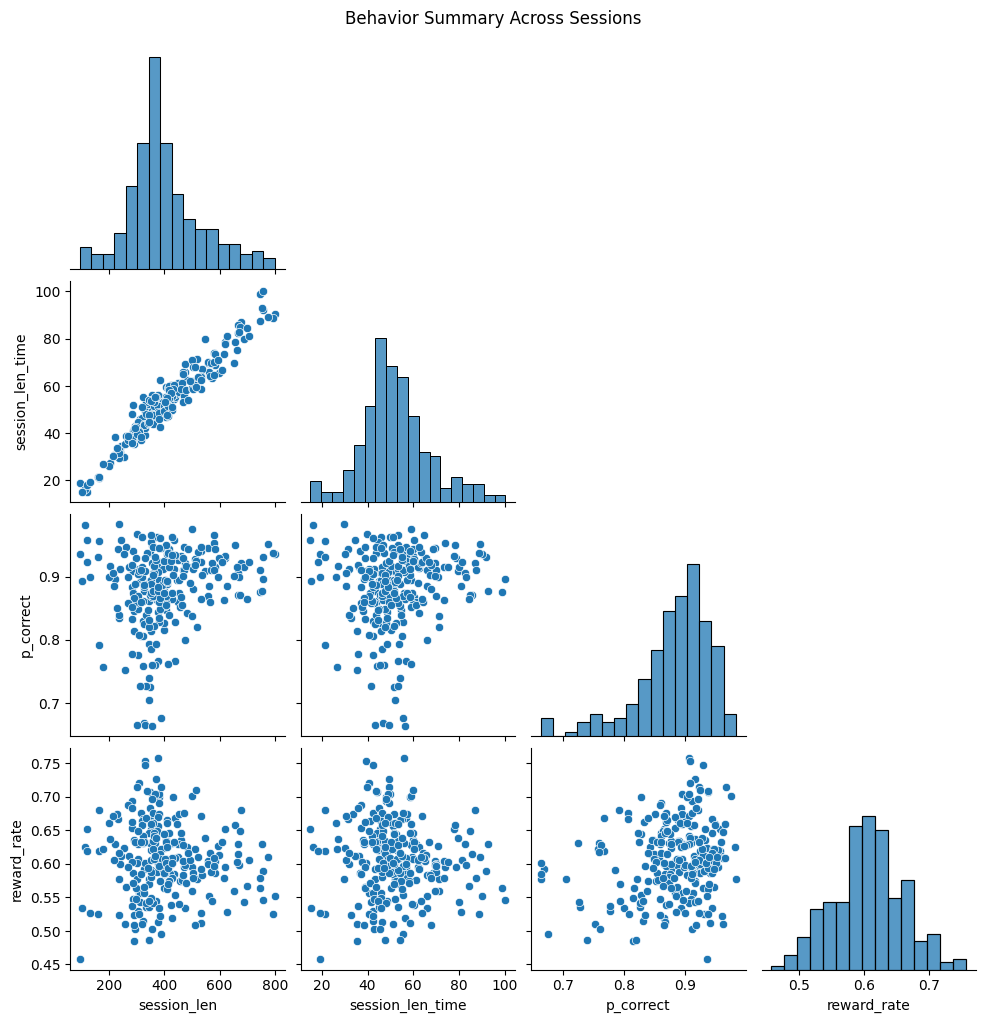

In [130]:
g = sns.pairplot(summary_df[['session_len', 'session_len_time', 'p_correct', 'reward_rate']], corner=True)
g.fig.suptitle('Behavior Summary Across Sessions', y=1.02)
plt.savefig(os.path.join(target_folder, 'model_prediction_summary_scatter.pdf'))

## RL parameters

## Reinforcement Learning Parameter Distributions

Visualize the distributions of fitted Q-learning parameters across sessions. The five key parameters are: learning rate for negative outcomes (aN), learning rate for positive outcomes (aP), learning rate for forgetting (aF), inverse temperature (beta) controlling choice stochasticity, and side bias. These distributions characterize the behavioral strategy employed by the animals in this photometry subset.

['/root/capsule/scratch/results/manuscript/figures/F_beh/FigureS12l_behavior_model_params_histogram.csv']

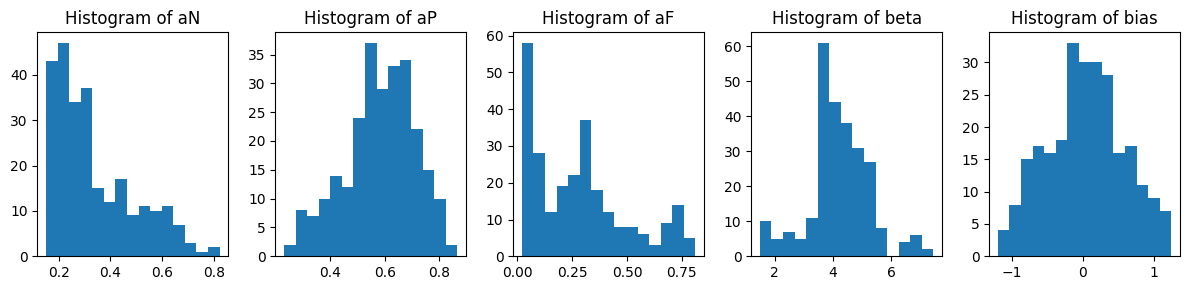

In [131]:
focus_params = ['aN', 'aP', 'aF', 'beta', 'bias']
fig, axes = plt.subplots(1, len(focus_params), figsize=(12,3))
for i, param in enumerate(focus_params):
    ax = axes[i]
    param_values = combined_session_tbl_filtered[param].dropna().values
    ax.hist(param_values, bins=15, edgecolor=None)
    ax.set_title(f'Histogram of {param}')
plt.tight_layout()
save_panels(fig, target_folder, 'behavior_model_params_histogram', ['FigureS12l'], exts=('pdf',))
save_panel_csv(columns_to_df(**{_p: combined_session_tbl_filtered[_p].dropna().values for _p in focus_params}), target_folder, 'behavior_model_params_histogram', ['FigureS12l'])
##FigureS12l##

## Policy against RPE

## Policy Update vs Reward Prediction Error

Examine the relationship between reward prediction error (RPE) and various policy update metrics. We bin trials by RPE magnitude and compute the average policy change in each bin. This analysis reveals how animals adjust their choice strategy in response to surprising outcomes. We present both analyses that combine all trials and analyses that average within-session curves.

In [151]:
policy_columns = ['policy_glm_change_log_odd']

In [152]:
all_session_combined = pd.concat(objs=all_sess_df, ignore_index=True)
num_bins = 9
bin_qualties = False

In [145]:
# fig, axes = plt.subplots(1, len(policy_columns), figsize=(15, 3))
# _c6 = {}
# for i, col in enumerate(policy_columns):
#     ax = axes[i]
#     data = all_session_combined[col].values
#     rpe = all_session_combined['pe'].values
#     valid_idx = ~np.isnan(data) & ~np.isnan(rpe)
#     data = data[valid_idx]
#     rpe = rpe[valid_idx]
#     if not bin_qualties:
#         bins = np.linspace(np.nanmin(rpe), np.nanmax(rpe), num_bins+1) 
#     else:
#         bins = np.quantile(rpe, np.linspace(0, 1, num_bins+1))
#     bin_means = np.full(num_bins, np.nan)
#     policy_means = np.full(num_bins, np.nan)
#     policy_sems = np.full(num_bins, np.nan)
#     for ind in range(num_bins):
#         bin_idx = (rpe >= bins[ind]) & (rpe < bins[ind+1])
#         if np.sum(bin_idx) > 0:
#             bin_means[ind] = np.nanmean(rpe[bin_idx])
#             policy_means[ind] = np.nanmean(data[bin_idx])
#             policy_sems[ind] = np.std(data[bin_idx])/np.sqrt(np.sum(bin_idx))
#     _c6[f'{col}_rpe'] = bin_means.copy(); _c6[f'{col}_mean'] = policy_means.copy(); _c6[f'{col}_sem'] = policy_sems.copy()
#     ax.errorbar(bin_means, policy_means, yerr=policy_sems, fmt='-o')
#     ax.set_xlabel('RPE')
#     ax.set_ylabel(col)
# plt.tight_layout()
# save_panels(fig, target_folder, 'policies_vs_rpe_all_combined', ['Figure6c_version1'], exts=('pdf',))
# save_panel_csv(columns_to_df(**_c6), target_folder, 'policies_vs_rpe_all_combined', ['Figure6c_version1'])
# ##Figure6c_version1##

## policy vs rpe, calculate by session then combine

['/root/capsule/scratch/results/manuscript/figures/F_beh/Figure6c_version2_policies_vs_rpe_session_avg.csv']

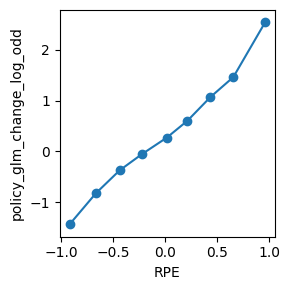

In [153]:
fig, axes = plt.subplots(1, len(policy_columns), figsize=(3*len(policy_columns), 3), squeeze=False)
_c6 = {}

for i, col in enumerate(policy_columns):
    ax = axes[0, i]
    policy_mat = []
    rpe_mat = []
    for sess_df in all_sess_df:
        data = sess_df[col].values
        rpe = sess_df['pe'].values
        valid_idx = ~np.isnan(data) & ~np.isnan(rpe)
        data = data[valid_idx]
        rpe = rpe[valid_idx]
        if len(data) == 0:
            continue
        if not bin_qualties:
            bins = np.linspace(np.nanmin(rpe), np.nanmax(rpe), num_bins+1) 
        else:
            bins = np.quantile(rpe, np.linspace(0, 1, num_bins+1))
        bin_means = np.full(num_bins, np.nan)
        policy_means = np.full(num_bins, np.nan)
        for ind in range(num_bins):
            bin_idx = (rpe >= bins[ind]) & (rpe < bins[ind+1])
            if np.sum(bin_idx) > 0:
                bin_means[ind] = np.nanmean(rpe[bin_idx])
                policy_means[ind] = np.nanmean(data[bin_idx])
        rpe_mat.append(bin_means)
        policy_mat.append(policy_means)
    rpe_mat = np.array(rpe_mat)
    policy_mat = np.array(policy_mat)
    mean_rpe = np.nanmean(rpe_mat, axis=0)
    mean_policy = np.nanmean(policy_mat, axis=0)
    sem_policy = np.nanstd(policy_mat, axis=0)/np.sqrt(np.sum(~np.isnan(policy_mat), axis=0))
    _c6[f'{col}_rpe'] = mean_rpe.copy(); _c6[f'{col}_mean'] = mean_policy.copy(); _c6[f'{col}_sem'] = sem_policy.copy()
    ax.errorbar(mean_rpe, mean_policy, yerr=sem_policy, fmt='-o')
    ax.set_xlabel('RPE')
    ax.set_ylabel(col)
plt.tight_layout()
save_panels(fig, target_folder, 'policies_vs_rpe_session_avg', ['Figure6c_version2'], exts=('pdf',))
save_panel_csv(columns_to_df(**_c6), target_folder, 'policies_vs_rpe_session_avg', ['Figure6c_version2'])
##Figure6c_version2##

## Lick rate vs rpe

## Lick Rate as Function of RPE

Analyze post-outcome lick rates as a function of RPE. Lick rate provides a continuous behavioral readout of reward expectation and valuation. We examine lick responses separately for positive and negative RPEs to capture asymmetries in how animals respond to better-than-expected versus worse-than-expected outcomes. Z-scored lick rates normalize within-session variability.

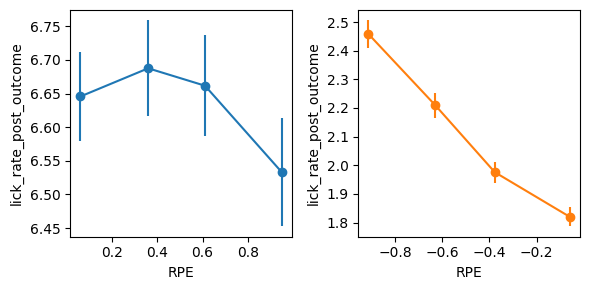

In [155]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
col = 'lick_rate_post_outcome'
lick_mat = []
rpe_mat = []
bin_quantiles = False
num_bins = 8
for sess_df in all_sess_df:
    data = sess_df[col].values
    rpe = sess_df['pe'].values
    valid_idx = ~np.isnan(data) & ~np.isnan(rpe)
    data = data[valid_idx]
    rpe = rpe[valid_idx]
    if len(data) == 0:
        continue
    if not bin_quantiles:
        bins = np.concat((np.linspace(-1, 0, num_bins//2 +1), np.linspace(0, 1, num_bins//2 +1)[1:]))
    else:
        bins = np.quantile(rpe, np.linspace(0, 1, num_bins+1))
    bin_means = np.full(num_bins, np.nan)
    lick_means = np.full(num_bins, np.nan)
    for ind in range(num_bins):
        bin_idx = (rpe >= bins[ind]) & (rpe < bins[ind+1])
        if np.sum(bin_idx) > 0:
            bin_means[ind] = np.nanmean(rpe[bin_idx])
            lick_means[ind] = np.nanmean(data[bin_idx])
    rpe_mat.append(bin_means)
    lick_mat.append(lick_means)
rpe_mat = np.array(rpe_mat)
lick_mat = np.array(lick_mat)
mean_rpe = np.nanmean(rpe_mat, axis=0)

mean_policy = np.nanmean(lick_mat, axis=0)
sem_policy = np.nanstd(lick_mat, axis=0)/np.sqrt(np.sum(~np.isnan(lick_mat), axis=0))
# plot lick with postive and negative rpe separately
ax = axes[0]
pos_idx = mean_rpe >= 0
ax.errorbar(mean_rpe[pos_idx], mean_policy[pos_idx], yerr=sem_policy[pos_idx], fmt='-o', color='tab:blue')
ax.set_xlabel('RPE')
ax.set_ylabel(col)
ax = axes[1]
neg_idx = mean_rpe < 0
ax.errorbar(mean_rpe[neg_idx], mean_policy[neg_idx], yerr=sem_policy[neg_idx], fmt='-o', color='tab:orange')
ax.set_xlabel('RPE')
ax.set_ylabel(col)
plt.tight_layout()
# save_panels(fig, target_folder, 'licks_vs_rpe_session_avg', ['FigureS12m_version1'], exts=('pdf',))
# save_panel_csv(columns_to_df(rpe=mean_rpe, lick_rate_mean=mean_policy, lick_rate_sem=sem_policy), target_folder, 'licks_vs_rpe_session_avg', ['FigureS12m_version1'])
##FigureS12m_version1##

['/root/capsule/scratch/results/manuscript/figures/F_beh/FigureS12m_version2_zscored_licks_vs_rpe_session_avg.csv']

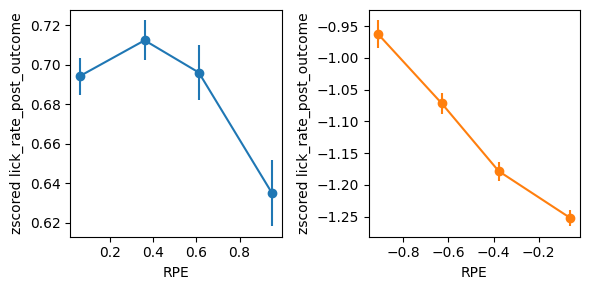

In [156]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
col = 'lick_rate_post_outcome'
lick_mat = []
rpe_mat = []
bin_quantiles = False
num_bins = 8
for sess_df in all_sess_df:
    data = sess_df[col].values
    # zscore
    data = zscore(data)
    rpe = sess_df['pe'].values
    valid_idx = ~np.isnan(data) & ~np.isnan(rpe)
    data = data[valid_idx]
    rpe = rpe[valid_idx]
    if len(data) == 0:
        continue
    if not bin_quantiles:
        bins = np.concat((np.linspace(-1, 0, num_bins//2 +1), np.linspace(0, 1, num_bins//2 +1)[1:]))
    else:
        bins = np.quantile(rpe, np.linspace(0, 1, num_bins+1))
    bin_means = np.full(num_bins, np.nan)
    lick_means = np.full(num_bins, np.nan)
    for ind in range(num_bins):
        bin_idx = (rpe >= bins[ind]) & (rpe < bins[ind+1])
        if np.sum(bin_idx) > 0:
            bin_means[ind] = np.nanmean(rpe[bin_idx])
            lick_means[ind] = np.nanmean(data[bin_idx])
    # lick_means[~np.isnan(lick_means)] = zscore(lick_means[~np.isnan(lick_means)])
    rpe_mat.append(bin_means)
    lick_mat.append(lick_means)
rpe_mat = np.array(rpe_mat)
lick_mat = np.array(lick_mat)
mean_rpe = np.nanmean(rpe_mat, axis=0)

mean_policy = np.nanmean(lick_mat, axis=0)
sem_policy = np.nanstd(lick_mat, axis=0)/np.sqrt(np.sum(~np.isnan(lick_mat), axis=0))
# plot lick with postive and negative rpe separately
ax = axes[0]
pos_idx = mean_rpe >= 0
ax.errorbar(mean_rpe[pos_idx], mean_policy[pos_idx], yerr=sem_policy[pos_idx], fmt='-o', color='tab:blue')
ax.set_xlabel('RPE')
ax.set_ylabel(f'zscored {col}')
ax = axes[1]
neg_idx = mean_rpe < 0
ax.errorbar(mean_rpe[neg_idx], mean_policy[neg_idx], yerr=sem_policy[neg_idx], fmt='-o', color='tab:orange')
ax.set_xlabel('RPE')
ax.set_ylabel(f'zscored {col}')
plt.tight_layout()
save_panels(fig, target_folder, 'zscored_licks_vs_rpe_session_avg', ['FigureS12m_version2'], exts=('pdf',))
save_panel_csv(columns_to_df(rpe=mean_rpe, zscored_lick_rate_mean=mean_policy, zscored_lick_rate_sem=sem_policy), target_folder, 'zscored_licks_vs_rpe_session_avg', ['FigureS12m_version2'])
##FigureS12m_version2##

## Categorical Comparisons of Behavioral Metrics

Compare behavioral metrics across discrete trial categories (rewarded vs unrewarded, switch vs stay). For each session, we compute the mean value of a metric within each category and visualize session-level averages. Points above the diagonal indicate higher values for category 1 versus category 0. Animal identity is color-coded to reveal individual differences.

In [157]:
def plot_scatter_by_category(plot_col, cate_col, panels=None):
    plot_mean_1 = []
    plot_mean_0 = []
    animal_ids = []
    for sess_df, session_id in zip(all_sess_df, processed_sessions):
        animal_id, _, _ = parseSessionID(session_id)
        data = sess_df[plot_col].values
        cat_val = sess_df[cate_col].values
        valid_idx = ~np.isnan(data) & ~np.isnan(cat_val)
        data = data[valid_idx]
        cat_val = cat_val[valid_idx]
        if len(data) == 0:
            continue
        plot_mean_1.append(np.nanmean(data[cat_val==1]))
        plot_mean_0.append(np.nanmean(data[cat_val==0]))
        animal_ids.append(animal_id)
    fig, ax = plt.subplots(figsize=(6,6))
    plot_df = pd.DataFrame({f'{plot_col}{cate_col}=1': plot_mean_1,
                                f'{plot_col}{cate_col}=0': plot_mean_0,
                                'animal_id': animal_ids})
    g = sns.scatterplot(data=plot_df, x=f'{plot_col}{cate_col}=0', y=f'{plot_col}{cate_col}=1', hue='animal_id', s=30, ax=ax)
    max_val = max(plot_df[f'{plot_col}{cate_col}=1'].max(), plot_df[f'{plot_col}{cate_col}=0'].max())
    ax.plot([0, max_val], [0, max_val], 'k--')
    ax.set_xlabel(f'Mean {plot_col} {cate_col}=0')
    ax.set_ylabel(f'Mean {plot_col} {cate_col}=1')
    plt.tight_layout()
    if panels is not None:
        save_panels(fig, target_folder, f'{plot_col}_{cate_col}_scatter_animal_color', panels, exts=('pdf',))
        save_panel_csv(plot_df, target_folder, f'{plot_col}_{cate_col}_scatter_animal_color', panels)
    else:
        plt.savefig(os.path.join(target_folder, f'{plot_col}_{cate_col}_scatter_animal_color.pdf'))
    print(f'Saved figure to {target_folder} as {plot_col}_{cate_col}_scatter_animal_color.pdf')

## Lick rate compare switch and stay

Saved figure to /root/capsule/scratch/results/manuscript/figures/F_beh as lick_lat_svs_scatter_animal_color.pdf


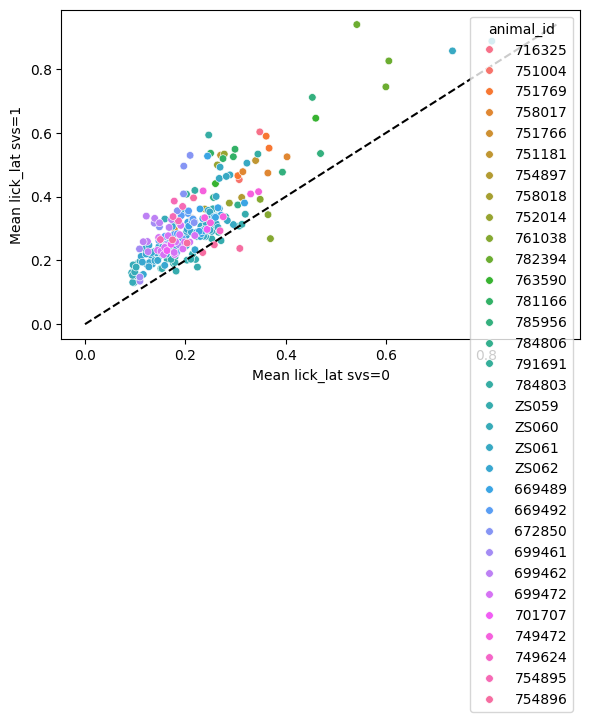

In [158]:
plot_scatter_by_category('lick_lat', 'svs')